# M4-B1 — Benchmark Mistral Assurances

> Concevoir une IA simple : benchmark 3+ familles de modèles + grille
> de décision. Référence baseline : `mistral-tarif-v1` (R² 0.39).

Auteur·rice : `Etienne` — Date : `18/08/2026`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append('../src')

RANDOM_STATE = 42
DATA_PATH = Path('../data/bike_sharing.csv')
sns.set_theme(style='whitegrid')

## 1. Reprise baseline mistral-tarif-v1 (~30 min)

Charge le modèle baseline depuis le repo `mistral-tarif-v1`, note ses
métriques rapportées (R² 0.39, MAE 105, RMSE 139), identifie les angles
morts du code 2024 (cf. mini-cours 04 méthodologie benchmark).

In [2]:
# Étape 1 — charger le baseline mistral-tarif-v1.
# Prérequis : cloner le repo baseline EN VOISIN de ton repo M4-B1
# (dans le dossier PARENT, pour que le chemin ../../ ci-dessous fonctionne) :
#   git clone https://github.com/Formation-SIMPLON-IA/mistral-tarif-v1.git
import joblib

# suppose le baseline cloné en voisin de ton repo M4-B1
model_v1 = joblib.load("../../mistral-tarif-v1/models/mistral_tarif_v1.joblib")
model_v1


LinearRegression()

## 2. EDA orientée saisonnalité (~1h30)

Au moins **4 visualisations Seaborn** : boxplot par saison, courbe par
heure-moyenne, scatter température vs cnt, corrélations.

> *« Quelle saisonnalité je vois ? Comment elle explique la
> sous-performance de la baseline ? »*

In [3]:
df = pd.read_csv(DATA_PATH)
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      17379 non-null  int64  
 1   date                    17379 non-null  object 
 2   season                  17379 non-null  object 
 3   year                    17379 non-null  int64  
 4   month                   17379 non-null  int64  
 5   hour                    17379 non-null  int64  
 6   is_holiday              17379 non-null  int64  
 7   weekday                 17379 non-null  int64  
 8   is_working_day          17379 non-null  int64  
 9   weather                 17379 non-null  int64  
 10  temperature_norm        17379 non-null  float64
 11  temperature_feels_norm  17379 non-null  float64
 12  humidity_norm           17379 non-null  float64
 13  windspeed_norm          17379 non-null  float64
 14  casual_riders           17379 non-null

,id,date,season,year,month,hour,is_holiday,weekday,is_working_day,weather,temperature_norm,temperature_feels_norm,humidity_norm,windspeed_norm,casual_riders,registered_riders,total_rentals
0,1,2011-01-01,winter,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,winter,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,winter,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


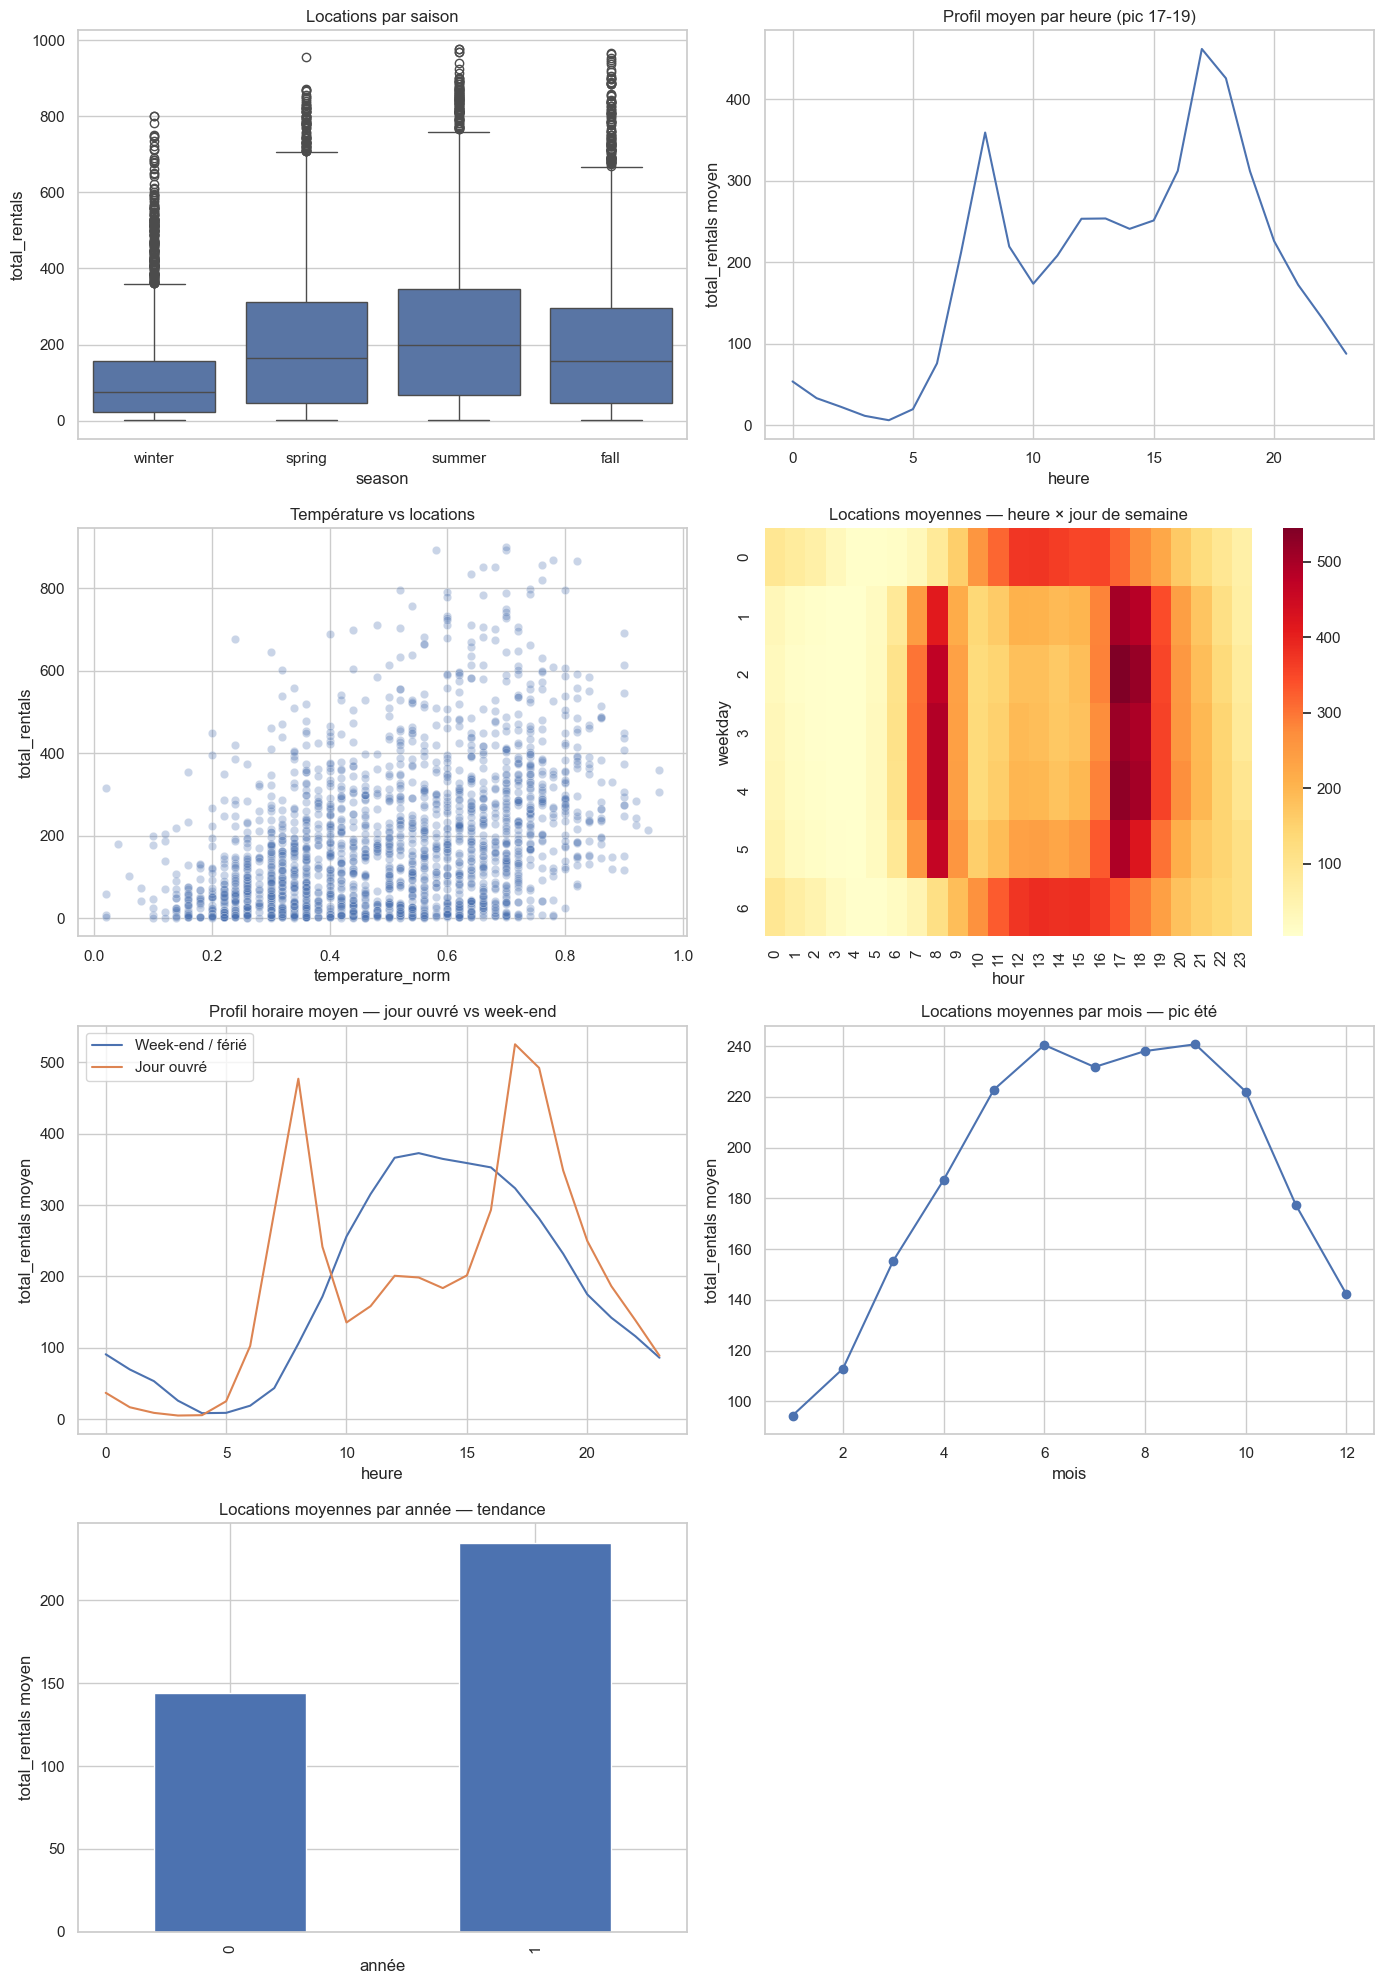

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

# 1. Distribution cible par saison
sns.boxplot(data=df, x="season", y="total_rentals", order=["winter", "spring", "summer", "fall"], ax=axes[0, 0])
axes[0, 0].set_title("Locations par saison")

# 2. Profil moyen par heure
df.groupby("hour")["total_rentals"].mean().plot(ax=axes[0, 1])
axes[0, 1].set_title("Profil moyen par heure (pic 17-19)")
axes[0, 1].set_xlabel("heure")
axes[0, 1].set_ylabel("total_rentals moyen")

# 3. Scatter température vs total_rentals
sns.scatterplot(data=df.sample(2000, random_state=RANDOM_STATE), x="temperature_norm", y="total_rentals", alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title("Température vs locations")

  # 4. Heatmap heure × weekday
pivot = df.pivot_table(values="total_rentals", index="weekday", columns="hour", aggfunc="mean")
sns.heatmap(pivot, cmap="YlOrRd", ax=axes[1, 1])
axes[1, 1].set_title("Locations moyennes — heure × jour de semaine")

# 5. Profil horaire selon le type de jour — interaction heure × jour ouvré
profil = df.groupby(["is_working_day","hour"])["total_rentals"].mean().unstack(0)
profil.columns = ["Week-end / férié", "Jour ouvré"]
profil.plot(ax=axes[2, 0])
axes[2, 0].set_title("Profil horaire moyen — jour ouvré vs week-end")
axes[2, 0].set_xlabel("heure")
axes[2, 0].set_ylabel("total_rentals moyen")

# 6. Saisonnalité mensuelle
df.groupby("month")["total_rentals"].mean().plot(marker="o", ax=axes[2, 1])
axes[2, 1].set_title("Locations moyennes par mois — pic été")
axes[2, 1].set_xlabel("mois")
axes[2, 1].set_ylabel("total_rentals moyen")

# 7. Tendance annuelle
df.groupby("year")["total_rentals"].mean().plot(kind="bar", ax=axes[3, 0])
axes[3, 0].set_title("Locations moyennes par année — tendance")
axes[3, 0].set_xlabel("année")
axes[3, 0].set_ylabel("total_rentals moyen")

axes[3, 1].axis("off")

plt.tight_layout()
plt.show()


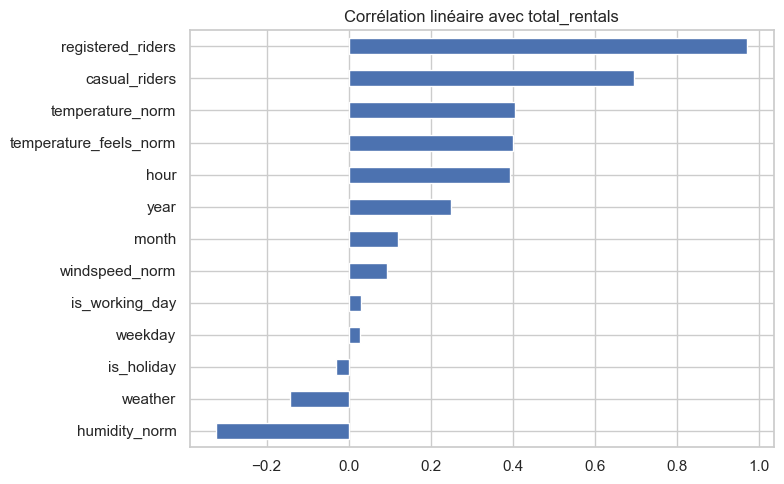

In [5]:
correlations = (df.select_dtypes('number').drop(columns=['id']).corr()['total_rentals'].drop('total_rentals').sort_values())
fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind='barh', ax=ax)
ax.set_title('Corrélation linéaire avec total_rentals')
plt.tight_layout()
plt.show()


### Conclusion de l'EDA

En 5 lignes maximum :

- Quelles variables semblent les plus importantes ? 
- Pourquoi la baseline linéaire risque-t-elle d'être limitée ? 
- Quelle famille de modèles t'attends-tu à voir gagner ?

Les variables les plus importantes pour moi sont hour et is_working_day, on peut ajouter temprature_norm qui a un impact et month
Le linéaire n'est pas adapté car il y a des pics et des creux en fonction des heures, et des différences entre weekend et semaine
Les modèles à base d'arbres ont des chances de gagner car ils seront plus efficaces sur les non linaires et les intéractions

## 3. Split argumenté + validation croisée (~30 min)

Choisir **`TimeSeriesSplit`** ou **`KFold` stratifié** — justifier.

Mini-cours 02 (split temporel vs stratifié) à consulter.

> 🎓 **Réflexe anti-fuite (la leçon de M2-B1, enfin mise en œuvre).** En M2-B1 tu
> as construit un `Pipeline` sans modèle ni split : la fuite ne pouvait pas se
> produire. Ici tu as **un split ET un modèle** → la règle s'applique : un
> préprocesseur **qui apprend des paramètres** (`StandardScaler`, `SimpleImputer`)
> ne se `fit` **jamais** sur l'ensemble des données. On l'enferme dans le
> `Pipeline` du modèle, et c'est **ce Pipeline** qu'on passe à la validation
> croisée — scikit-learn re-`fit` alors le scaler sur les seuls folds
> d'entraînement. Sinon : fuite → R² **optimiste mensonger**. On le démontre
> juste en dessous.

In [6]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

df = df.sort_values(['date', 'hour']).reset_index(drop=True)

splitter = TimeSeriesSplit(n_splits=5)
splitter


TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

Les données sont une série datée et on demande de prédire la demande future.

### 🔬 Fuites de données — démonstration (à faire une fois)

La cellule compare **trois** situations en validation croisée (Ridge) :
la **fuite de cible** (`casual_riders`/`registered_riders` dans X — ils
somment la cible), la **fuite de prétraitement** (`StandardScaler` fitté sur
**tout** X avant la CV) et la version **propre** (scaler dans le `Pipeline`).

> **À rédiger après exécution** (2-3 phrases, → journal de bord) : la fuite de
> cible crève l'écran (R² ≈ 1.0) ; la fuite de prétraitement est **quasi
> invisible ici** (~±0.0005 sur 17k lignes, parfois même légèrement négative —
> c'est du bruit). Explique *dans quel cas* elle exploserait (peu de données,
> imputation moyenne/médiane, encodage supervisé) — et donc pourquoi on
> encapsule le prétraitement **par défaut** : cette fuite-là ne prévient pas.


In [7]:
# 🔬 Démonstration fuites vs propre (Ridge) — à exécuter une fois le
# preprocessing complété (FEATURES rempli dans preprocess.py).
# Cellule pré-écrite : tu n'as pas à la coder, juste à la faire tourner.
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from preprocess import load_dataset

try:
    X_demo, y_demo = load_dataset(DATA_PATH)   # SANS casual_riders / registered_riders
    df_full = pd.read_csv(DATA_PATH)
    splitter_demo = TimeSeriesSplit(n_splits=5)
    pipe = lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0))

    # (0) FUITE DE CIBLE : les composantes de y remises dans X
    X_cible = X_demo.assign(casual_riders=df_full["casual_riders"],
                            registered_riders=df_full["registered_riders"])
    r2_cible = cross_val_score(pipe(), X_cible, y_demo, cv=splitter_demo, scoring="r2").mean()

    # (1) FUITE DE PRÉTRAITEMENT : le scaler est fitté sur TOUT X, avant la CV
    X_leak = StandardScaler().fit_transform(X_demo)
    r2_leak = cross_val_score(Ridge(alpha=1.0), X_leak, y_demo, cv=splitter_demo, scoring="r2").mean()

    # (2) PROPRE : le scaler vit DANS le pipeline -> re-fitté sur chaque fold d'entraînement
    r2_clean = cross_val_score(pipe(), X_demo, y_demo, cv=splitter_demo, scoring="r2").mean()

    display(pd.DataFrame(
        {"R² moyen (CV)": [round(r2_cible, 4), round(r2_leak, 4), round(r2_clean, 4)],
         "écart vs propre": [format(r2_cible - r2_clean, "+.4f"),
                             format(r2_leak - r2_clean, "+.5f"), "—"]},
        index=["fuite de CIBLE (riders dans X)",
               "fuite de PRÉTRAITEMENT (scaler global)",
               "propre (scaler dans le pipeline)"],
    ))
except Exception as e:
    print(f"⏳ Démo à relancer une fois preprocess.load_dataset opérationnel (FEATURES rempli). Détail : {e}")


,R² moyen (CV),écart vs propre
fuite de CIBLE (riders dans X),1.0000,+0.7722
fuite de PRÉTRAITEMENT (scaler global),0.2278,+0.00000
propre (scaler dans le pipeline),0.2278,—


## 4. Benchmark — 3 familles minimum (~2h)

**Famille A** — Linéaire (Ridge ou variante)  
**Famille B** — Arbre / RandomForest  
**Famille C** — Gradient Boosting (HistGradientBoostingRegressor)

Pour chaque modèle :
- Mêmes folds, mêmes métriques
- MAE, RMSE, R²
- Temps train, latence inférence
- Persistance `.joblib` dans `models/`

> ⚠️ **Règle d'or** : réutilise **exactement le même splitter** que la section 3 (Split). Un splitter différent d'un modèle à l'autre = comparaison invalide.


In [8]:
import time
import joblib
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

X, y = load_dataset(DATA_PATH)

EXPLICABILITE = {'baseline-v1 (2024)': 3, 'Ridge': 3, 'RandomForest': 2, 'HistGB': 2}

resultats = []

features_v1 = list(model_v1.feature_names_in_)
df_v1 = df.copy()
df_v1['season'] = df_v1['season'].map({'winter': 1, 'spring': 2, 'summer': 3, 'fall': 4})
X_v1, y_v1 = df_v1[features_v1], df_v1['total_rentals']

maes, rmses, r2s = [], [], []
for _, test_idx in splitter.split(X_v1, y_v1):
    y_true = y_v1.iloc[test_idx]
    y_pred = model_v1.predict(X_v1.iloc[test_idx])
    maes.append(mean_absolute_error(y_true, y_pred))
    rmses.append(root_mean_squared_error(y_true, y_pred))
    r2s.append(r2_score(y_true, y_pred))

t0 = time.perf_counter()
_ = model_v1.predict(X_v1.iloc[:1000])
pred_ms_v1 = (time.perf_counter() - t0) * 1000

resultats.append({
    'model': 'baseline-v1 (2024)',
    'mae_mean': np.mean(maes), 'mae_std': np.std(maes),
    'rmse_mean': np.mean(rmses), 'rmse_std': np.std(rmses),
    'r2_mean': np.mean(r2s), 'r2_std': np.std(r2s),
    'fit_time_sec': np.nan,         
    'pred_ms_per_1k': pred_ms_v1,
    'taille_mo': round(Path('../../mistral-tarif-v1/models/mistral_tarif_v1.joblib').stat().st_size / 1e6, 3),
    'explicabilite': EXPLICABILITE['baseline-v1 (2024)'],
})

models = {
    'Ridge': lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'RandomForest': lambda: RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1),
    'HistGB': lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

for nom, factory in models.items():
    modele = factory()

    mae = -cross_val_score(modele, X, y, cv=splitter, scoring='neg_mean_absolute_error')
    rmse = -cross_val_score(modele, X, y, cv=splitter, scoring='neg_root_mean_squared_error')
    r2 = cross_val_score(modele, X, y, cv=splitter, scoring='r2')

    t0 = time.perf_counter()
    modele.fit(X, y)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    _ = modele.predict(X.iloc[:1000])
    pred_ms = (time.perf_counter() - t0) * 1000

    chemin = MODELS_DIR / f'{nom}.joblib'
    joblib.dump(modele, chemin)

    resultats.append({
        'model': nom,
        'mae_mean': mae.mean(), 'mae_std': mae.std(),
        'rmse_mean': rmse.mean(), 'rmse_std': rmse.std(),
        'r2_mean': r2.mean(), 'r2_std': r2.std(),
        'fit_time_sec': fit_time,
        'pred_ms_per_1k': pred_ms,
        'taille_mo': round(chemin.stat().st_size / 1e6, 3),
        'explicabilite': EXPLICABILITE[nom],
    })

tableau = pd.DataFrame(resultats).set_index('model').round(4)
tableau

C:\Users\eti3n\Code\formation_IA\M4-B1-mistral-etienne\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\eti3n\Code\formation_IA\M4-B1-mistral-etienne\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\eti3n\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\eti3n\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_f

,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,fit_time_sec,pred_ms_per_1k,taille_mo,explicabilite
model,,,,,,,,,,
baseline-v1 (2024),114.3542,24.1882,147.7820,29.2465,0.3234,0.0076,NaN,0.7927,0.001,3
Ridge,117.9415,23.6689,156.8898,26.8577,0.2278,0.0589,0.0054,0.9423,0.002,3
RandomForest,52.9292,16.2109,79.3039,23.4590,0.7804,0.1381,4.5930,15.8050,150.134,2
HistGB,51.8135,16.3027,76.3286,23.5944,0.7959,0.1340,0.3936,4.7311,0.368,2


## 5. Tableau comparatif (~30 min, mercredi)

Remplis `benchmark_table.md` avec les chiffres + interprétation pour
Inès Tabet (lisible actuaire, pas data scientist).

## 6. Verdict + decision card (~30 min, mercredi)

- `verdict.md` : 5 lignes max, recommandation chiffrée
- `decision_card.md` : ta version perso de la grille de décision C4
  (à confronter à la collective)

## 7. Restitution + grille collective (mercredi 11h30-12h45)

**Geste pédagogique central** — co-construction de la grille de
décision C4 sur Excalidraw partagé.

Archivée ensuite dans `ressources-publiques/grille_decision_C4.md`.